- Implement Gaussian/Laplacian Pyramid
- Demonstrate scale-space analysis
- Show object detection at multiple scales

In [1]:
from pathlib import Path
import sys

# BASE_DIR = Path(__file__).resolve().parent
BASE_DIR = Path().resolve().parent

sys.path.append(str(BASE_DIR))

train_path = BASE_DIR / "data" / "raw" / "Training"
test_path = BASE_DIR / "data" / "raw" / "Testing"

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from modules.data_loader import load_data
from modules.preprocessing import standardize

X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# Apply preprocessing to the loaded data
X_train = [standardize(img) for img in X_train]
X_test = [standardize(img) for img in X_test]

In [ ]:
import cv2
import matplotlib.pyplot as plt

# A Gaussian pyramid is a sequence of images where each level is:
# blurred
# then downsampled (reduced size)
def gaussian_pyramid(img, levels=4):
    gp = [img]
    for i in range(levels):
        img = cv2.pyrDown(img)
        gp.append(img)
    return gp


# A Laplacian pyramid shows the difference between Gaussian levels
# It captures the lost details between scales
def laplacian_pyramid(gp):
    lp = []
    for i in range(len(gp)-1):
        size = (gp[i].shape[1], gp[i].shape[0])
        up = cv2.pyrUp(gp[i+1], dstsize=size)
        lp.append(cv2.subtract(gp[i], up))
    return lp

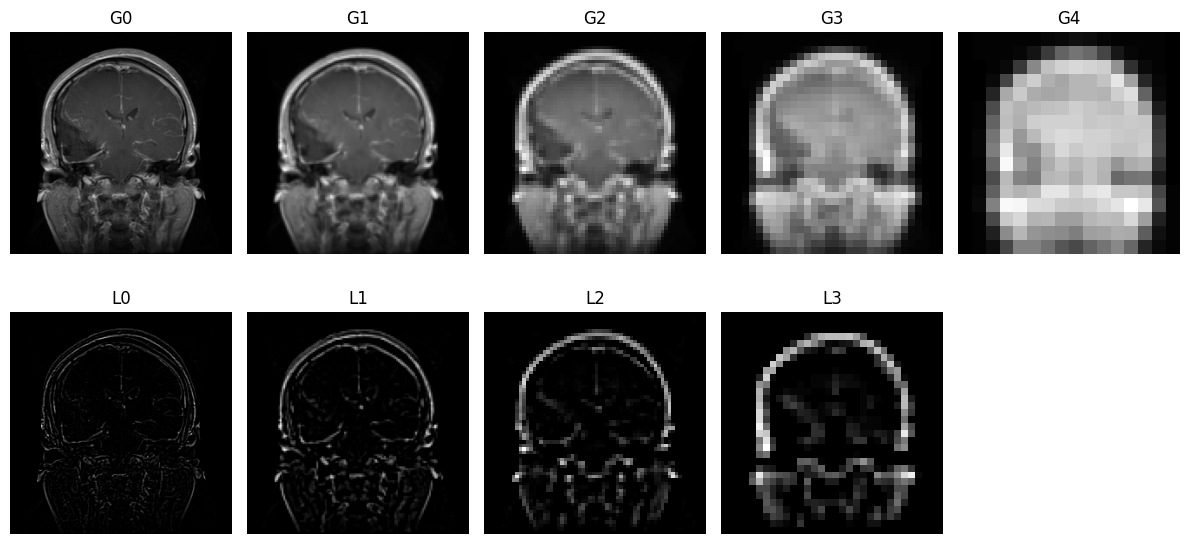

In [5]:
img = X_train[0]

gp = gaussian_pyramid(img)
lp = laplacian_pyramid(gp)

cols = len(gp)

plt.figure(figsize=(12, 6))

# Gaussian pyramid
for i in range(len(gp)):
    plt.subplot(2, cols, i + 1)
    plt.imshow(gp[i], cmap="gray")
    plt.title(f"G{i}")
    plt.axis("off")

# Laplacian pyramid
for i in range(len(lp)):
    plt.subplot(2, cols, cols + i + 1)
    plt.imshow(lp[i], cmap="gray")
    plt.title(f"L{i}")
    plt.axis("off")

plt.tight_layout()
plt.show()